In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

# Load data
DATA_PATH = "./Final_datasets/telemetry_final_windandwaveTRAVIATA.parquet"
df = pd.read_parquet(DATA_PATH)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Loaded data shape:", df.shape)
df.head()

Loaded data shape: (404138, 33)


,timestamp,Draught_A_m,Draught_F_m,Latitude_deg,Longitude_deg,SpeedOverGround_kn,HeadingTrue_deg,SpeedThroughWater_kn,WindAngleRelative_deg,WindSpeedRelative_m_s,...,wind_dir_10m,current_speed_ms,current_dir,HeadingTrue_deg_360,ShaftPower_kW_smooth,ShaftRev_rpm_smooth,SpeedThroughWater_kn_smooth,SpeedOverGround_kn_smooth,wind_speed_10m_ms_smooth,current_speed_ms_smooth
0,2023-01-01 03:18:00+00:00,10.566667,11.305000,8.026458,75.095459,16.746500,-64.083333,17.756666,21.600000,6.840000,...,181.936737,0.442182,128.261658,295.916667,10094.176389,91.946852,17.756083,16.749324,3.434551,0.436836
1,2023-01-01 03:19:00+00:00,10.570000,11.316667,8.028206,75.091414,16.760000,-63.983333,17.735000,20.000000,6.866667,...,182.021820,0.440575,128.201294,296.016667,10094.625000,91.949014,17.756532,16.750391,3.433983,0.437002
2,2023-01-01 03:20:00+00:00,10.560000,11.290000,8.030018,75.087233,16.783501,-63.950000,17.723332,20.166667,7.100000,...,182.109833,0.438939,128.131958,296.050000,10095.242188,91.951493,17.756979,16.751416,3.433401,0.437183
3,2023-01-01 03:21:00+00:00,10.565000,11.320000,8.031967,75.082724,16.800833,-64.000000,17.758334,19.600000,6.560000,...,182.204453,0.437357,128.067871,296.000000,10096.112374,91.954478,17.757576,16.752447,3.432798,0.437413
4,2023-01-01 03:22:00+00:00,10.565000,11.290000,8.033756,75.078592,16.769800,-64.000000,17.765001,20.166667,7.966667,...,182.291122,0.436824,128.109863,296.000000,10097.160539,91.957876,17.758333,16.753673,3.432146,0.437683


In [23]:
df.describe()

,Draught_A_m,Draught_F_m,Latitude_deg,Longitude_deg,SpeedOverGround_kn,HeadingTrue_deg,SpeedThroughWater_kn,WindAngleRelative_deg,WindSpeedRelative_m_s,ShaftPower_kW,...,wind_dir_10m,current_speed_ms,current_dir,HeadingTrue_deg_360,ShaftPower_kW_smooth,ShaftRev_rpm_smooth,SpeedThroughWater_kn_smooth,SpeedOverGround_kn_smooth,wind_speed_10m_ms_smooth,current_speed_ms_smooth
count,404138.000000,404138.000000,404138.000000,404138.000000,404138.000000,404138.000000,404138.000000,404138.000000,404138.000000,404138.000000,...,404138.000000,404138.000000,404138.000000,404138.000000,404138.000000,404138.000000,404138.000000,404138.000000,404138.000000,404138.000000
mean,9.849876,10.248495,11.387013,30.546139,15.289912,-14.230249,15.215624,186.728960,10.101655,6559.351164,...,191.941330,0.247235,186.728180,185.691263,6553.998707,78.456000,15.217904,15.290458,6.503879,0.246941
std,0.647899,0.956117,27.885280,86.902508,2.089804,98.534234,2.005995,133.253653,5.454640,2188.532625,...,104.859367,0.203882,101.171158,102.492676,2159.920437,9.887491,1.973684,2.053798,2.909084,0.195348
min,7.705000,7.175000,-39.208003,-179.996378,4.786200,-180.000000,5.055000,0.000000,0.150000,808.100000,...,0.000946,0.000013,0.000122,0.000000,907.920076,40.071278,6.510586,5.636825,0.149833,0.007351
25%,9.665000,10.015000,-14.436469,-13.141016,14.358667,-102.900001,14.366667,52.166667,5.516667,5233.000000,...,96.859131,0.114058,98.997734,89.583334,5245.772889,72.931090,14.373281,14.381547,4.452244,0.120391
50%,10.000000,10.493333,13.841053,23.065478,15.481000,-28.266667,15.346667,213.600000,9.620000,6443.333333,...,202.606697,0.193977,198.037354,203.883333,6447.323074,79.358643,15.342312,15.474819,6.428729,0.193854
75%,10.320000,10.960000,35.177096,109.276021,16.550167,78.216667,16.386667,318.666667,14.340000,8032.583333,...,288.050064,0.317847,270.562401,269.966667,8011.917882,84.950648,16.354401,16.523339,8.392474,0.312692
max,11.250000,12.445000,58.691474,179.994734,21.627667,180.000000,20.005000,359.000000,30.189315,12905.200000,...,359.999298,2.034348,359.999176,360.000000,12655.249306,96.945845,19.646916,20.635684,17.044929,1.981700


In [24]:
df2 = df[
    (
        (df["WindAngleRelative_deg"] >= 315) | 
        (df["WindAngleRelative_deg"] <= 45)
    )
    & (df["swh"] > 4)
]


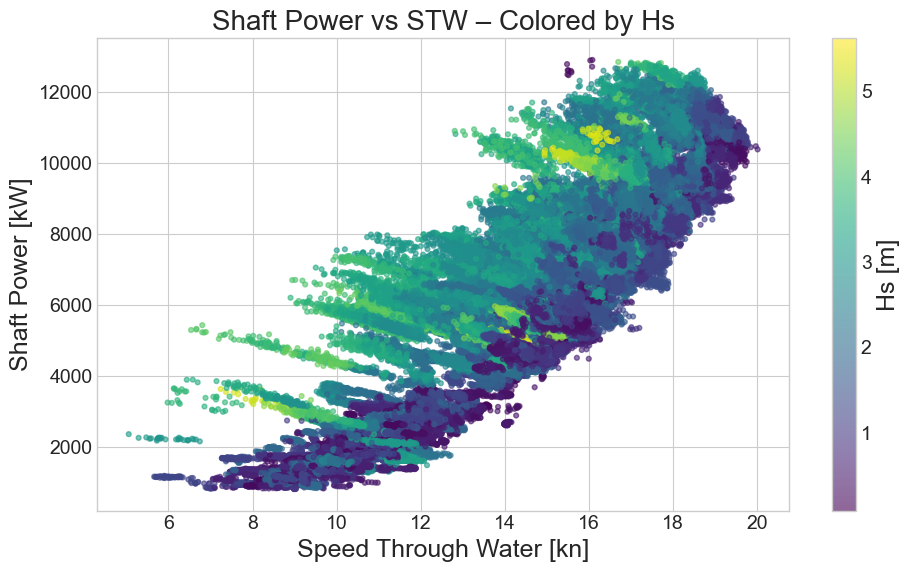

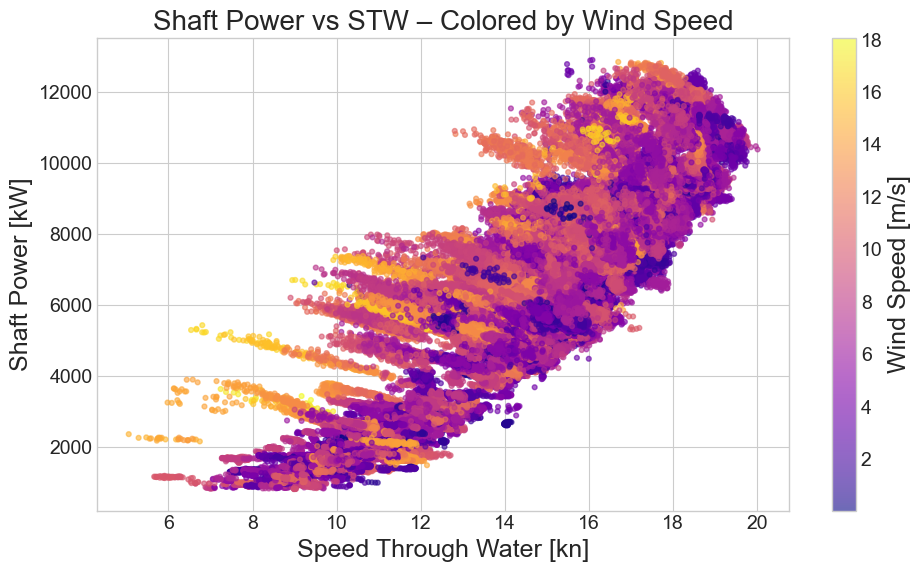

In [29]:
import matplotlib.pyplot as plt

# Global font settings (optional but convenient)
plt.rcParams.update({
    "font.size": 16,           # base font size
    "axes.titlesize": 20,      # title size
    "axes.labelsize": 18,      # x/y label size
    "xtick.labelsize": 14,     # tick label size
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
    "figure.titlesize": 22
})

# Plot 1: Hs
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    df["SpeedThroughWater_kn"],
    df["ShaftPower_kW"],
    c=df["swh"],
    cmap="viridis",
    s=12,
    alpha=0.6
)
plt.xlabel("Speed Through Water [kn]")
plt.ylabel("Shaft Power [kW]")
plt.title("Shaft Power vs STW – Colored by Hs")
cbar = plt.colorbar(sc)
cbar.set_label("Hs [m]", fontsize=18)
plt.tight_layout()
plt.show()

# Plot 2: Wind Speed
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    df["SpeedThroughWater_kn"],
    df["ShaftPower_kW"],
    c=df["wind_speed_10m_ms"],
    cmap="plasma",
    s=12,
    alpha=0.6
)
plt.xlabel("Speed Through Water [kn]")
plt.ylabel("Shaft Power [kW]")
plt.title("Shaft Power vs STW – Colored by Wind Speed")
cbar = plt.colorbar(sc)
cbar.set_label("Wind Speed [m/s]", fontsize=18)
plt.tight_layout()
plt.show()


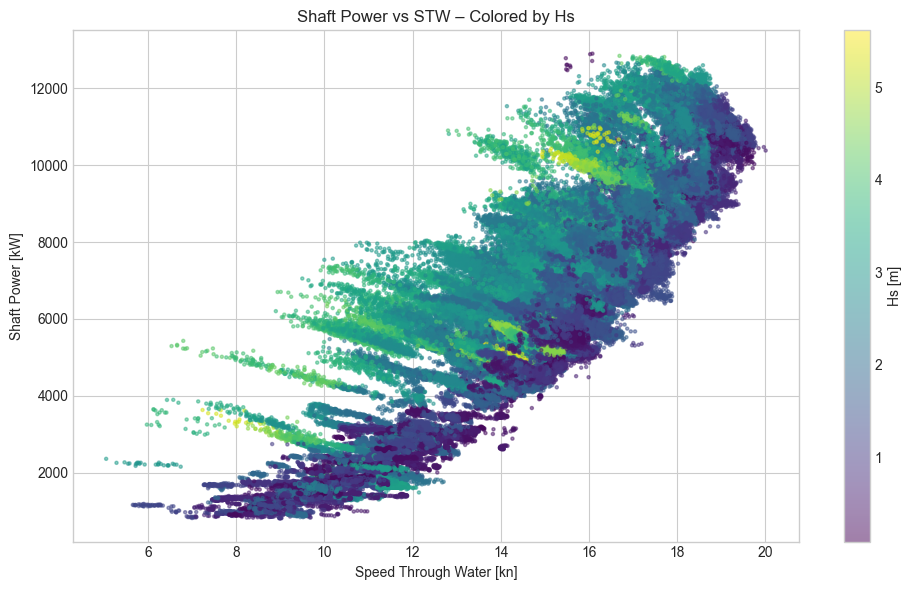

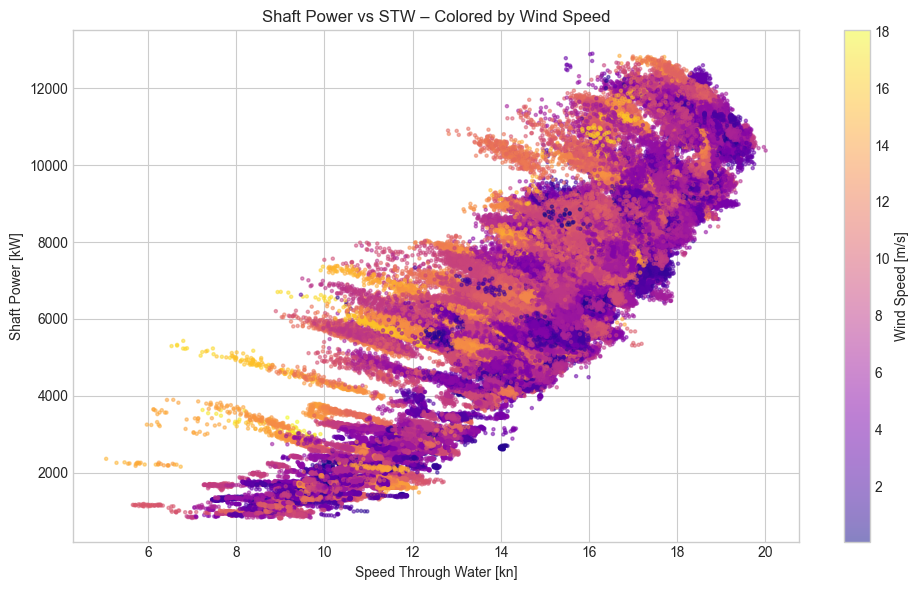

In [28]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(df["SpeedThroughWater_kn"], df["ShaftPower_kW"], c=df["swh"], cmap="viridis", s=5, alpha=0.5)
plt.xlabel("Speed Through Water [kn]")
plt.ylabel("Shaft Power [kW]")
plt.title("Shaft Power vs STW – Colored by Hs")
plt.colorbar(sc).set_label("Hs [m]")
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))
sc = plt.scatter(df["SpeedThroughWater_kn"], df["ShaftPower_kW"], c=df["wind_speed_10m_ms"], cmap="plasma", s=5, alpha=0.5)
plt.xlabel("Speed Through Water [kn]")
plt.ylabel("Shaft Power [kW]")
plt.title("Shaft Power vs STW – Colored by Wind Speed")
plt.colorbar(sc).set_label("Wind Speed [m/s]")
plt.tight_layout()
plt.show()


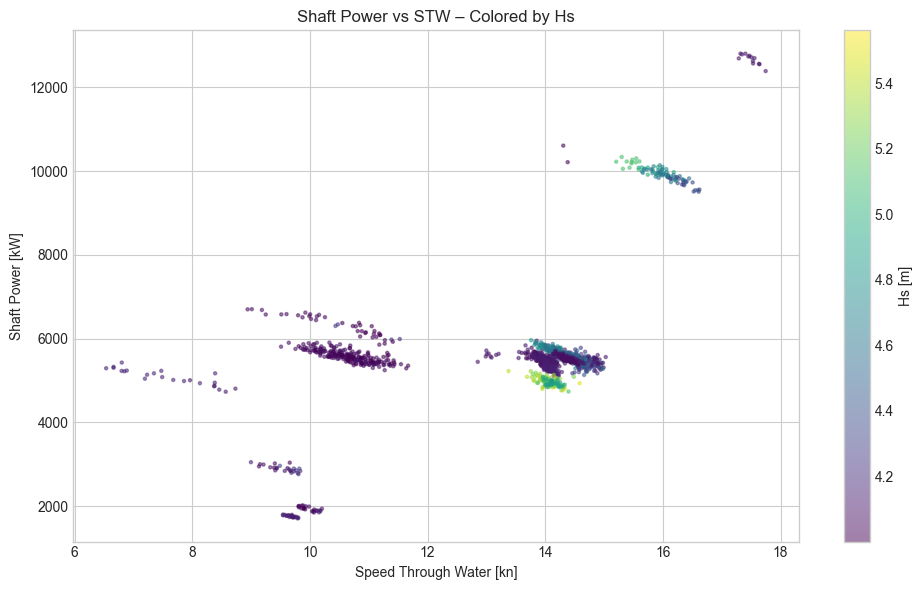

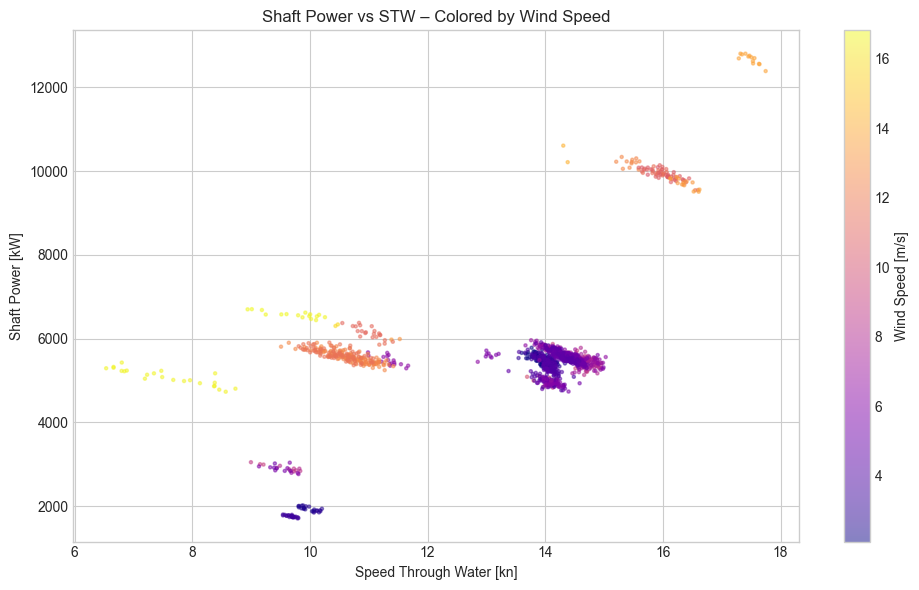

In [26]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(df2["SpeedThroughWater_kn"], df2["ShaftPower_kW"], c=df2["swh"], cmap="viridis", s=5, alpha=0.5)
plt.xlabel("Speed Through Water [kn]")
plt.ylabel("Shaft Power [kW]")
plt.title("Shaft Power vs STW – Colored by Hs")
plt.colorbar(sc).set_label("Hs [m]")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sc = plt.scatter(df2["SpeedThroughWater_kn"], df2["ShaftPower_kW"], c=df2["wind_speed_10m_ms"], cmap="plasma", s=5, alpha=0.5)
plt.xlabel("Speed Through Water [kn]")
plt.ylabel("Shaft Power [kW]")
plt.title("Shaft Power vs STW – Colored by Wind Speed")
plt.colorbar(sc).set_label("Wind Speed [m/s]")
plt.tight_layout()
plt.show()